You’ll build 3 models on the same dataset:
```
| Model   | Architecture    | Idea                     |
| ------- | --------------- | ------------------------ |
| Model 1 | No hidden layer | Underfitting             |
| Model 2 | 2 neurons       | Better fit               |
| Model 3 | 8–16 neurons    | Even better (or overfit) |


In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Step 1: Create Simple Non-Linear Data

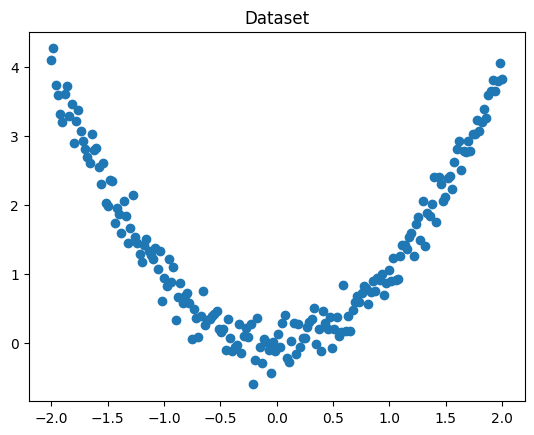

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Non-linear dataset
X = np.linspace(-2, 2, 200)
y = X**2 + np.random.normal(0, 0.2, 200)

X = X.reshape(-1, 1)
y = y.reshape(-1, 1)

plt.scatter(X, y)
plt.title("Dataset")
plt.show()


# Step 2: Build Models

c:\Users\hi\Desktop\projects\python_projects\tutorial\tut_tensorflow\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [14]:
# Model 1: No Hidden Layer (Underfitting)

model1 = models.Sequential([
    layers.Dense(1, input_shape=(1,))
])

model1.compile(optimizer='adam', loss='mse')
history1 = model1.fit(X, y, epochs=100, verbose=0)


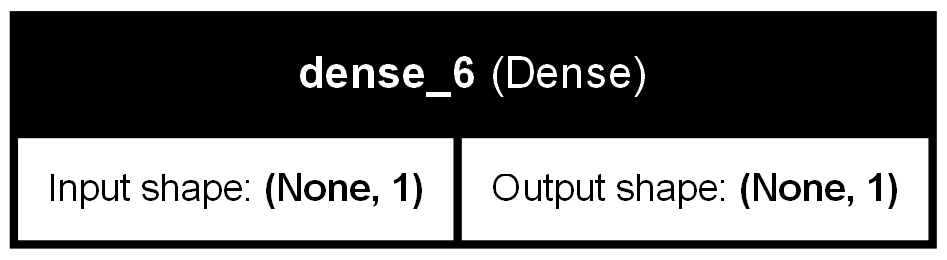

In [15]:
# Lets visualize
from tensorflow.keras.utils import plot_model

plot_model(
    model1,
    to_file='model.png',
    show_shapes=True,
    show_layer_names=True,
    rankdir='LR'   # TB Top to Bottom (vertical)
)


In [12]:
# Model 2: Small Network (2 neurons)

model2 = models.Sequential([
    layers.Dense(2, activation='relu', input_shape=(1,)),
    layers.Dense(1)
])

model2.compile(optimizer='adam', loss='mse')
history2 = model2.fit(X, y, epochs=100, verbose=0)

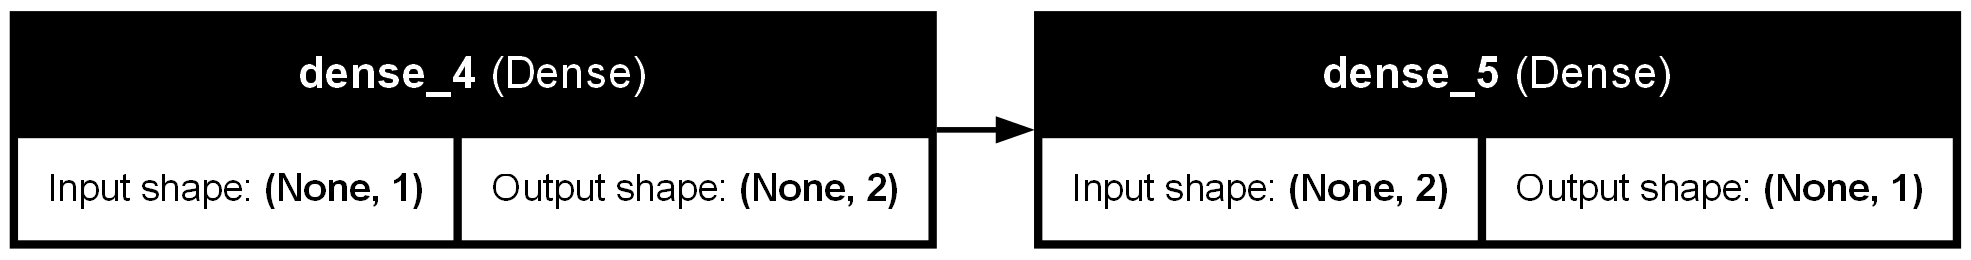

In [13]:
# Lets visualize
from tensorflow.keras.utils import plot_model

plot_model(
    model2,
    to_file='model.png',
    show_shapes=True,
    show_layer_names=True,
    rankdir='LR'   # TB Top to Bottom (vertical)
)


In [7]:
# Model 3: Bigger Network
model3 = models.Sequential([
    layers.Dense(16, activation='relu', input_shape=(1,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

model3.compile(optimizer='adam', loss='mse')
history3 = model3.fit(X, y, epochs=100, verbose=0)


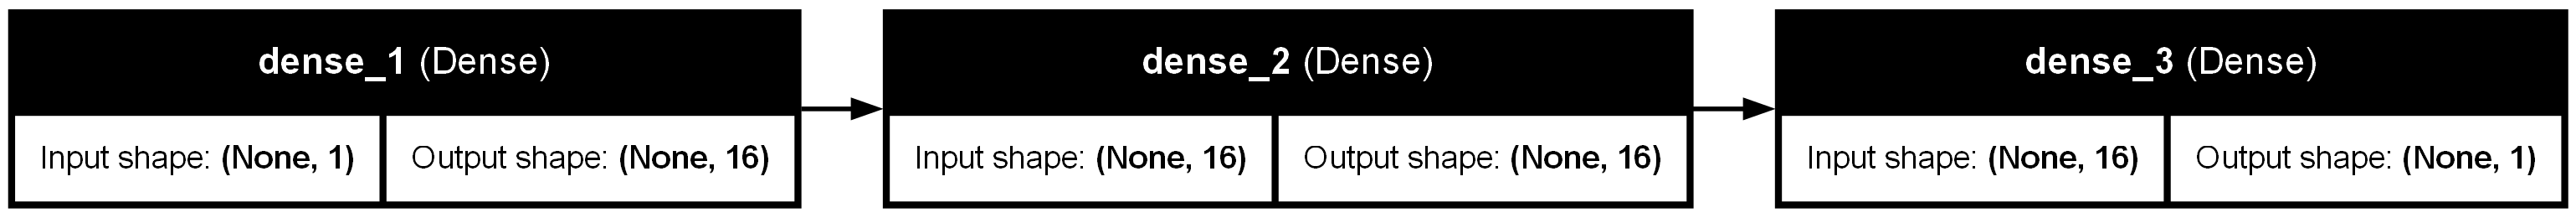

In [10]:
# Lets visualize
from tensorflow.keras.utils import plot_model

plot_model(
    model3,
    to_file='model.png',
    show_shapes=True,
    show_layer_names=True,
    rankdir='LR'   # TB , Top to Bottom (vertical)
)


# Step 3: Compare Errors

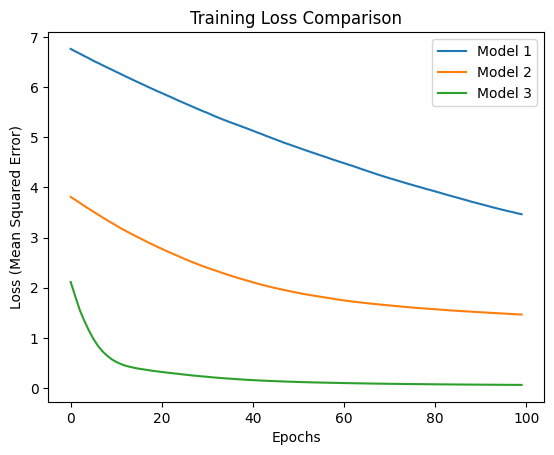

In [10]:
plt.plot(history1.history['loss'], label='Model 1')
plt.plot(history2.history['loss'], label='Model 2')
plt.plot(history3.history['loss'], label='Model 3')

plt.xlabel("Epochs")                 # X-axis
plt.ylabel("Loss (Mean Squared Error)")  # Y-axis

plt.legend()
plt.title("Training Loss Comparison")
plt.show()


In [ ]:
# Model3 with more neurons has less error:

In [ ]:
# Step 4: Visual Comparison (VERY IMPACTFUL)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


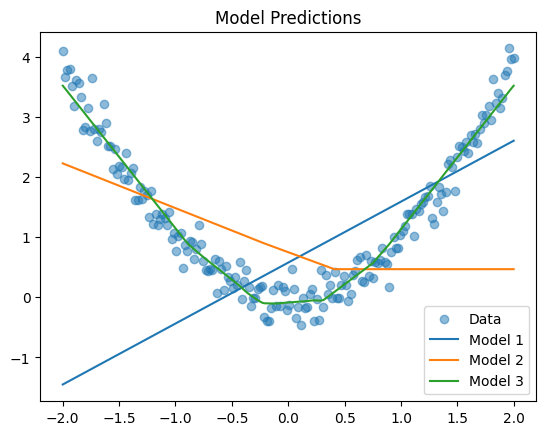

In [8]:
pred1 = model1.predict(X)
pred2 = model2.predict(X)
pred3 = model3.predict(X)

plt.scatter(X, y, label="Data", alpha=0.5)
plt.plot(X, pred1, label="Model 1")
plt.plot(X, pred2, label="Model 2")
plt.plot(X, pred3, label="Model 3")

plt.legend()
plt.title("Model Predictions")
plt.show()
